### KNN Regression



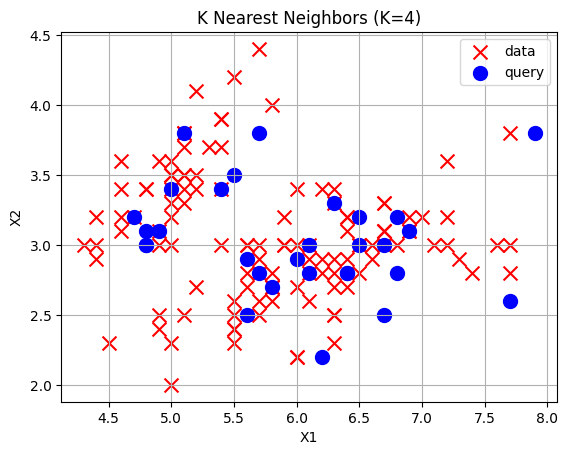

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split

np.random.seed(42)

class KNN():
    def __init__(self, K):
        self.K = K

    def euclidean_distance(self, x1, x2):
        dist = 0
        for i in range(len(x1)):
            dist += np.power((x1[i] - x2[i]), 2)
        return np.sqrt(dist)

    def knn_search(self, X_train, y_train, Q):
        y_pred = np.empty(Q.shape[0])

        for i, query in enumerate(Q):
            #get K nearest neighbors to query point
            idx = np.argsort([self.euclidean_distance(query, x) for x in X_train])[:self.K]
            #extract the labels of KNN training labels
            knn_labels = np.array([y_train[i] for i in idx])
            #label query sample as the average of knn_labels
            y_pred[i] = np.mean(knn_labels)

        return y_pred


if __name__ == "__main__":

    plt.close('all')

    #iris dataset
    iris = datasets.load_iris()
    X = iris.data[:,:2]
    y = iris.target

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    K = 4
    knn = KNN(K)
    y_pred = knn.knn_search(X_train, y_train, X_test)

    plt.figure(1)
    plt.scatter(X_train[:,0], X_train[:,1], s = 100, marker = 'x', color = 'r', label = 'data')
    plt.scatter(X_test[:,0], X_test[:,1], s = 100, marker = 'o', color = 'b', label = 'query')
    plt.title('K Nearest Neighbors (K=%d)'% K)
    plt.legend()
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.grid(True)
    plt.show()
